In [ ]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start')
import os
import jax.numpy as jnp
import math
import scipy.constants as C
import numpy as np
from typing import Union, Tuple
from EM_analyzer.Lorentz.Lorentz_transform import LorentzTransform
from EM_analyzer.plot.plot_1D import plot_multiple_1D_fields
from EM_analyzer.plot.plot_2D import plot_2D_field

In [2]:
lorentz_transform = LorentzTransform(
    beta_x=0,
    beta_y=np.sin(np.radians(45)),
    beta_z=0
    )
print(lorentz_transform)
print(lorentz_transform.transform_matrix)

LorentzTransform(v=[0.00e+00, 2.12e+08, 0.00e+00] m/s, β=[0.000000, 0.707107, 0.000000], |β|=0.707107, γ=1.4142, ξ=0.8814, c=3.00e+08 m/s)
[[ 1.41421356 -0.         -1.         -0.        ]
 [-0.          1.          0.          0.        ]
 [-1.          0.          1.41421356  0.        ]
 [-0.          0.          0.          1.        ]]


In [3]:
theta_degree=45
theta_rad=jnp.radians(theta_degree)

laser_lambda = 0.875*C.micron		# Laser wavelength
laser_f0=1/laser_lambda
laser_k0=2*C.pi*laser_f0
laser_omega0=(2*C.pi*C.speed_of_light)/(laser_lambda)
laser_period=laser_lambda/C.speed_of_light
laser_a0=1		# Laser field strength
laser_Bc=(C.m_e*laser_omega0)/(C.elementary_charge)
laser_Ec=laser_Bc*C.speed_of_light   #4.013376e+12V/m
laser_Sc=C.epsilon_0*C.speed_of_light*laser_Ec**2/2   #1.327e+18 W/m^2
laser_amp=laser_a0*laser_Ec
laser_FWHM=8*C.femto   #The full width at half maximum of the intensity.
laser_tau=laser_FWHM/math.sqrt(2*math.log(2)) 
#laser_tau=laser_period/jnp.sqrt(jnp.pi)
laser_Nc=laser_omega0**2*C.m_e*C.epsilon_0/C.elementary_charge**2
laser_S0=C.epsilon_0*C.speed_of_light*laser_amp**2/2   #average Poynting vector

target_N=200

cells_per_lambda =2000
vacuum_length_x_lambda=20   #lambda
continuation_length_lambda=2000   #lambda
space_length_lambda=vacuum_length_x_lambda+2*continuation_length_lambda   #lambda
n_field_x=round(vacuum_length_x_lambda*cells_per_lambda)
n_continuation_x=round(space_length_lambda*cells_per_lambda)

d_x=laser_lambda/cells_per_lambda   #unit: m
d_f=1/(space_length_lambda*laser_lambda)   #unit: 1/m, d_x*d_f=1/n_continuation_x

print('λ0/dx=',laser_lambda/d_x)
print('f0/df=',laser_f0/d_f)

laser_lambda_M=laser_lambda/math.cos(theta_rad)
laser_period_M=laser_period/math.cos(theta_rad)
laser_tau_M=laser_tau/math.cos(theta_rad)
laser_f0_M=laser_f0*math.cos(theta_rad)
laser_k0_M=laser_k0*math.cos(theta_rad)
laser_Bc_M=laser_Bc*math.cos(theta_rad)
laser_Ec_M=laser_Ec*math.cos(theta_rad)
laser_Nc_M=laser_Nc/math.cos(theta_rad)
laser_Sc_M=laser_Sc*math.cos(theta_rad)**2
laser_amp_M=laser_amp*math.cos(theta_rad)
laser_S0_M=laser_S0*math.cos(theta_rad)**2
vacuum_length_x_lambda_M=vacuum_length_x_lambda*math.cos(theta_rad)
space_length_lambda_M=space_length_lambda*math.cos(theta_rad)   #laser_f0_M/d_f

laser_spectrum_peak_M=laser_amp_M*(math.sqrt(C.pi)/2)*(laser_tau_M*C.speed_of_light)*(1-math.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2))
laser_energy_M=laser_amp_M**2*math.sqrt(C.pi/2)*(laser_tau_M*C.speed_of_light/2)*(1-math.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2/2))
laser_envelope_integral_M=laser_amp_M**2*(laser_tau_M*C.speed_of_light)*math.sqrt(C.pi/2)

plasma_cutoff_order=jnp.sqrt(target_N/(math.cos(theta_rad))**3)

highest_harmonic=100000

λ0/dx= 2000.0
f0/df= 4020.0000000000005


In [4]:
working_dir='/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/without_collision'

In [5]:
data_dict=read_sdf(
    sdf_name=os.path.join(working_dir,'0000.sdf'),
    block_name_list=[
        'Electric_Field_Ex','Electric_Field_Ey','Electric_Field_Ez',
        'Magnetic_Field_Bx','Magnetic_Field_By','Magnetic_Field_Bz',
        'Derived_Number_Density_Electron','Derived_Jx_Electron','Derived_Jy_Electron','Derived_Jz_Electron',]
    )
Electric_Field_Ex_M=data_dict['Electric_Field_Ex']
Electric_Field_Ey_M=data_dict['Electric_Field_Ey']
Electric_Field_Ez_M=data_dict['Electric_Field_Ez']
Magnetic_Field_Bx_M=data_dict['Magnetic_Field_Bx']
Magnetic_Field_By_M=data_dict['Magnetic_Field_By']
Magnetic_Field_Bz_M=data_dict['Magnetic_Field_Bz']
Derived_Number_Density_Electron=data_dict['Derived_Number_Density_Electron']
Derived_Jx_Electron=data_dict['Derived_Jx_Electron']
Derived_Jy_Electron=data_dict['Derived_Jy_Electron']
Derived_Jz_Electron=data_dict['Derived_Jz_Electron']
x_coordinate=data_dict['x']

Reading file /scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/without_collision/0000.sdf
t() = time
bx(80000,) = bx
by(80000,) = by
bz(80000,) = bz
ex(80000,) = ex
ey(80000,) = ey
ez(80000,) = ez
jx(80000,) = jx
jy(80000,) = jy
jz(80000,) = jz
x(80001,) = grid
xc(80000,) = grid_mid
vx_electron(342766,) = Particles/Vx/Electron
vx_h_ion(73452,) = Particles/Vx/H_ion
vx_c_ion(146865,) = Particles/Vx/C_ion
vx_o_ion(122422,) = Particles/Vx/O_ion
vy_electron(342766,) = Particles/Vy/Electron
vy_h_ion(73452,) = Particles/Vy/H_ion
vy_c_ion(146865,) = Particles/Vy/C_ion
vy_o_ion(122422,) = Particles/Vy/O_ion
id_electron(342766,) = Particles/ID/Electron
id_h_ion(73452,) = Particles/ID/H_ion
id_c_ion(146865,) = Particles/ID/C_ion
id_o_ion(122422,) = Particles/ID/O_ion
x_grid_electron(342766,) = Grid_Particles_Electron x
x_grid_h_ion(73452,) = Grid_Particles_H_ion x
x_grid_c_ion(146865,) = Grid_Particles_C_ion x
x_grid_o_ion(122422,) = Grid_Particles_O_ion x


{'fig': <Figure size 800x600 with 1 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>}

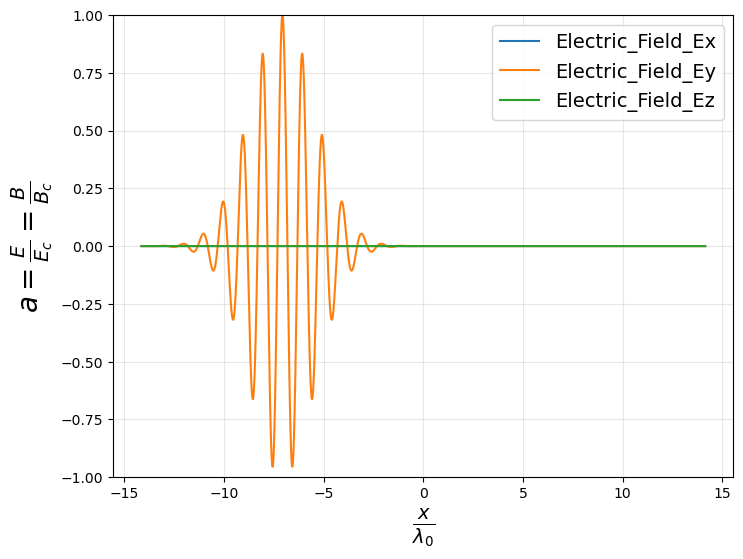

In [6]:
plot_multiple_1D_fields(
    coordinate=x_coordinate/laser_lambda_M,
    field_dict_list=[
        {'field':Electric_Field_Ex_M/laser_Ec_M,'label':'Electric_Field_Ex'},
        {'field':Electric_Field_Ey_M/laser_Ec_M,'label':'Electric_Field_Ey'},
        {'field':Electric_Field_Ez_M/laser_Ec_M,'label':'Electric_Field_Ez'},
    ],
    ymin=-1,ymax=1,
)

{'fig': <Figure size 800x600 with 1 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>}

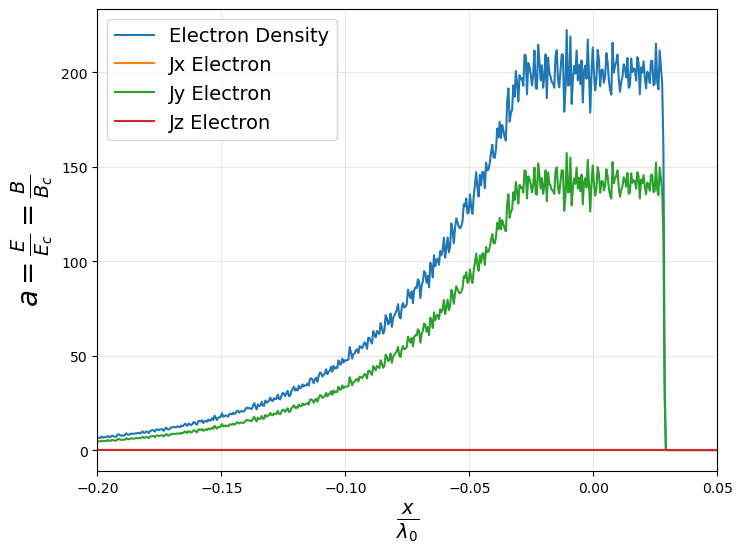

In [7]:
plot_multiple_1D_fields(
    x_coordinate/laser_lambda,
    field_dict_list=[
        {'field': Derived_Number_Density_Electron/laser_Nc_M, 'label': 'Electron Density'},
        {'field': Derived_Jx_Electron/(laser_Nc_M*C.elementary_charge*C.speed_of_light), 'label': 'Jx Electron'},
        {'field': Derived_Jy_Electron/(laser_Nc_M*C.elementary_charge*C.speed_of_light), 'label': 'Jy Electron'},
        {'field': Derived_Jz_Electron/(laser_Nc_M*C.elementary_charge*C.speed_of_light), 'label': 'Jz Electron'},
    ],
    xmin=-0.2,xmax=0.05,
)

In [8]:
Nx=len(x_coordinate)
Ny=Nx//2
zoom=0.1
step=round(1/zoom)
Electric_Field_Ex_M=jnp.broadcast_to(Electric_Field_Ex_M[:,jnp.newaxis],(Nx,Ny))[::step,::step]
Electric_Field_Ey_M=jnp.broadcast_to(Electric_Field_Ey_M[:,jnp.newaxis],(Nx,Ny))[::step,::step]
Electric_Field_Ez_M=jnp.broadcast_to(Electric_Field_Ez_M[:,jnp.newaxis],(Nx,Ny))[::step,::step]
Magnetic_Field_Bx_M=jnp.broadcast_to(Magnetic_Field_Bx_M[:,jnp.newaxis],(Nx,Ny))[::step,::step]
Magnetic_Field_By_M=jnp.broadcast_to(Magnetic_Field_By_M[:,jnp.newaxis],(Nx,Ny))[::step,::step]
Magnetic_Field_Bz_M=jnp.broadcast_to(Magnetic_Field_Bz_M[:,jnp.newaxis],(Nx,Ny))[::step,::step]

figure size= [18.50150038 10.5       ] inch
ax_main position= Bbox(x0=0.16214901165737455, y0=0.09523809523809523, x1=0.8108261530663963, y1=0.6666666666666666)


{'fig': <Figure size 1850.15x1050 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: title={'center': 'y=0.00'}, xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: title={'center': 'x=0.00'}, xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar_0': <Axes: ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_legend': <Axes: >,
 'ax_cbar': <Axes: ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>}

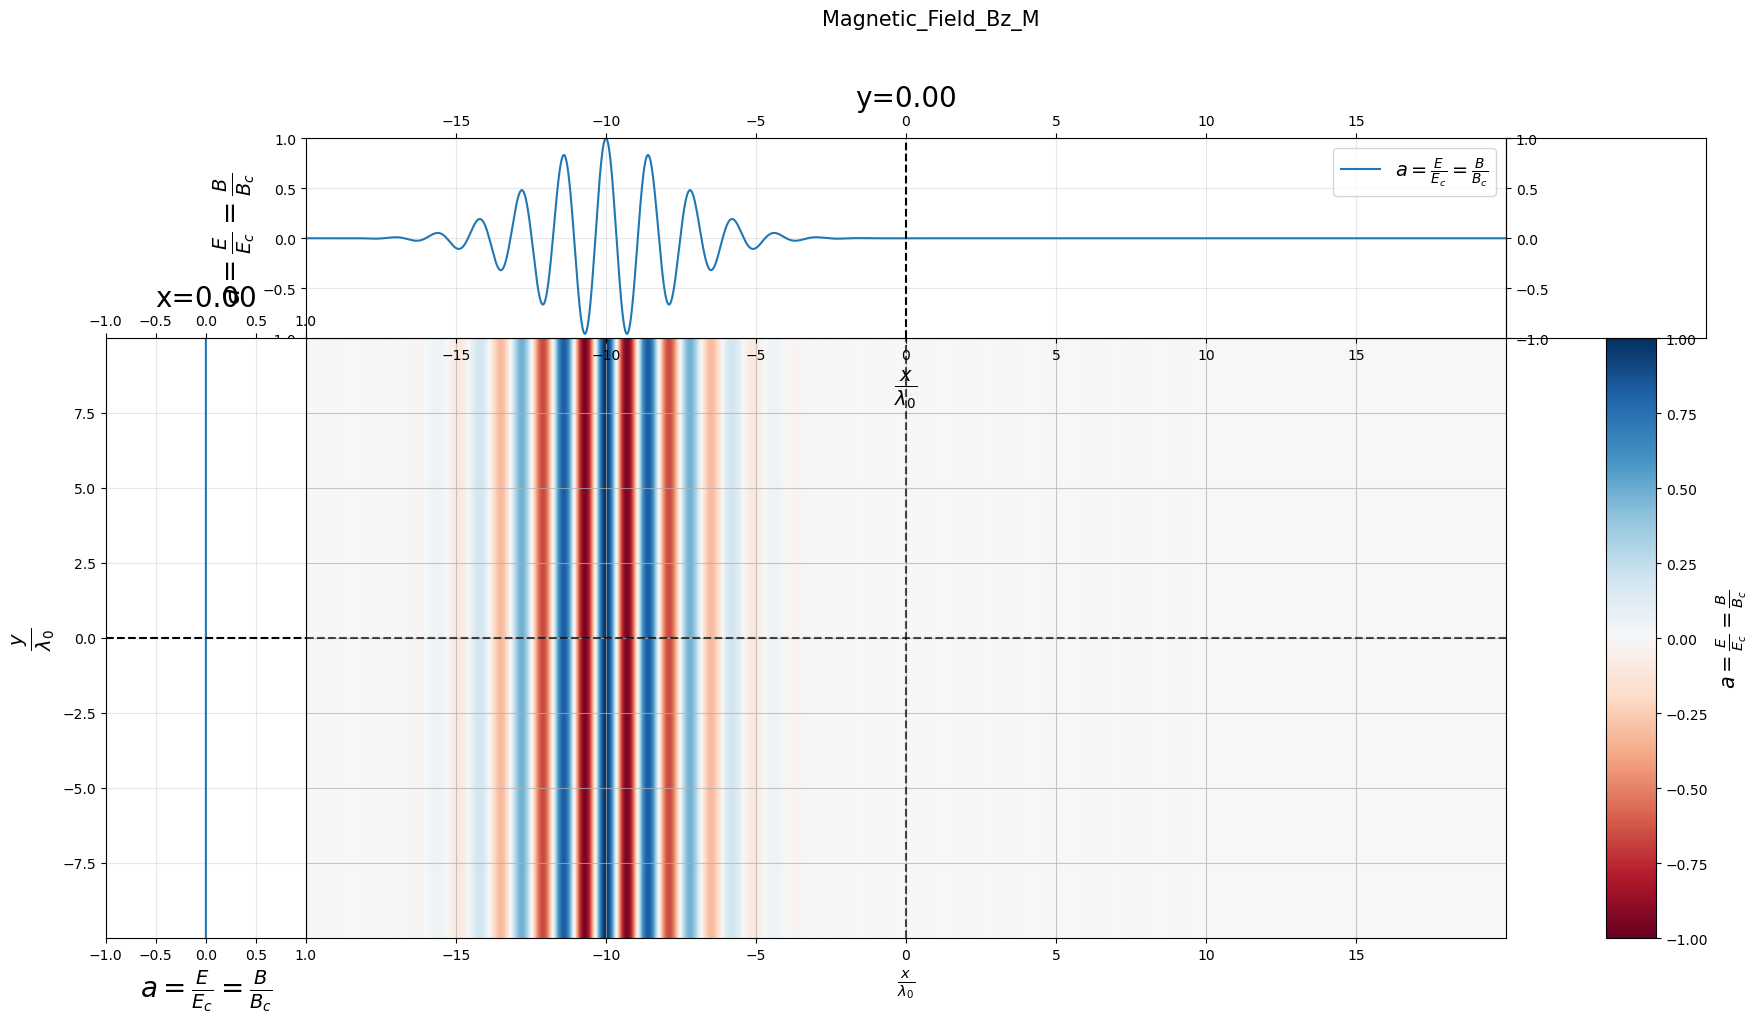

In [10]:
plot_2D_field(
    field=Magnetic_Field_Bz_M/laser_Bc_M,
    x_coordinate=x_coordinate[::step]/laser_lambda,
    y_coordinate=x_coordinate[Nx//4:Nx//4+Ny:step]/laser_lambda,
    name='Magnetic_Field_Bz_M',
    x_profile_id=round(zoom*Nx//2),y_profile_id=round(zoom*Ny//2),
)

In [11]:
E_transformed, B_transformed=lorentz_transform.transform_electromagnetic_field(
    E_field=[Electric_Field_Ex_M,Electric_Field_Ey_M,Electric_Field_Ez_M],
    B_field=[Magnetic_Field_Bx_M,Magnetic_Field_By_M,Magnetic_Field_Bz_M],
    direction='1->0',
)

figure size= [18.50150038 10.5       ] inch
ax_main position= Bbox(x0=0.16214901165737455, y0=0.09523809523809523, x1=0.8108261530663963, y1=0.6666666666666666)


{'fig': <Figure size 1850.15x1050 with 5 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_panel_top': <Axes: title={'center': 'y=0.00'}, xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: title={'center': 'x=0.00'}, xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='$\\frac{y}{\\lambda_0}$'>,
 'ax_cbar_0': <Axes: ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_legend': <Axes: >,
 'ax_cbar': <Axes: ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>}

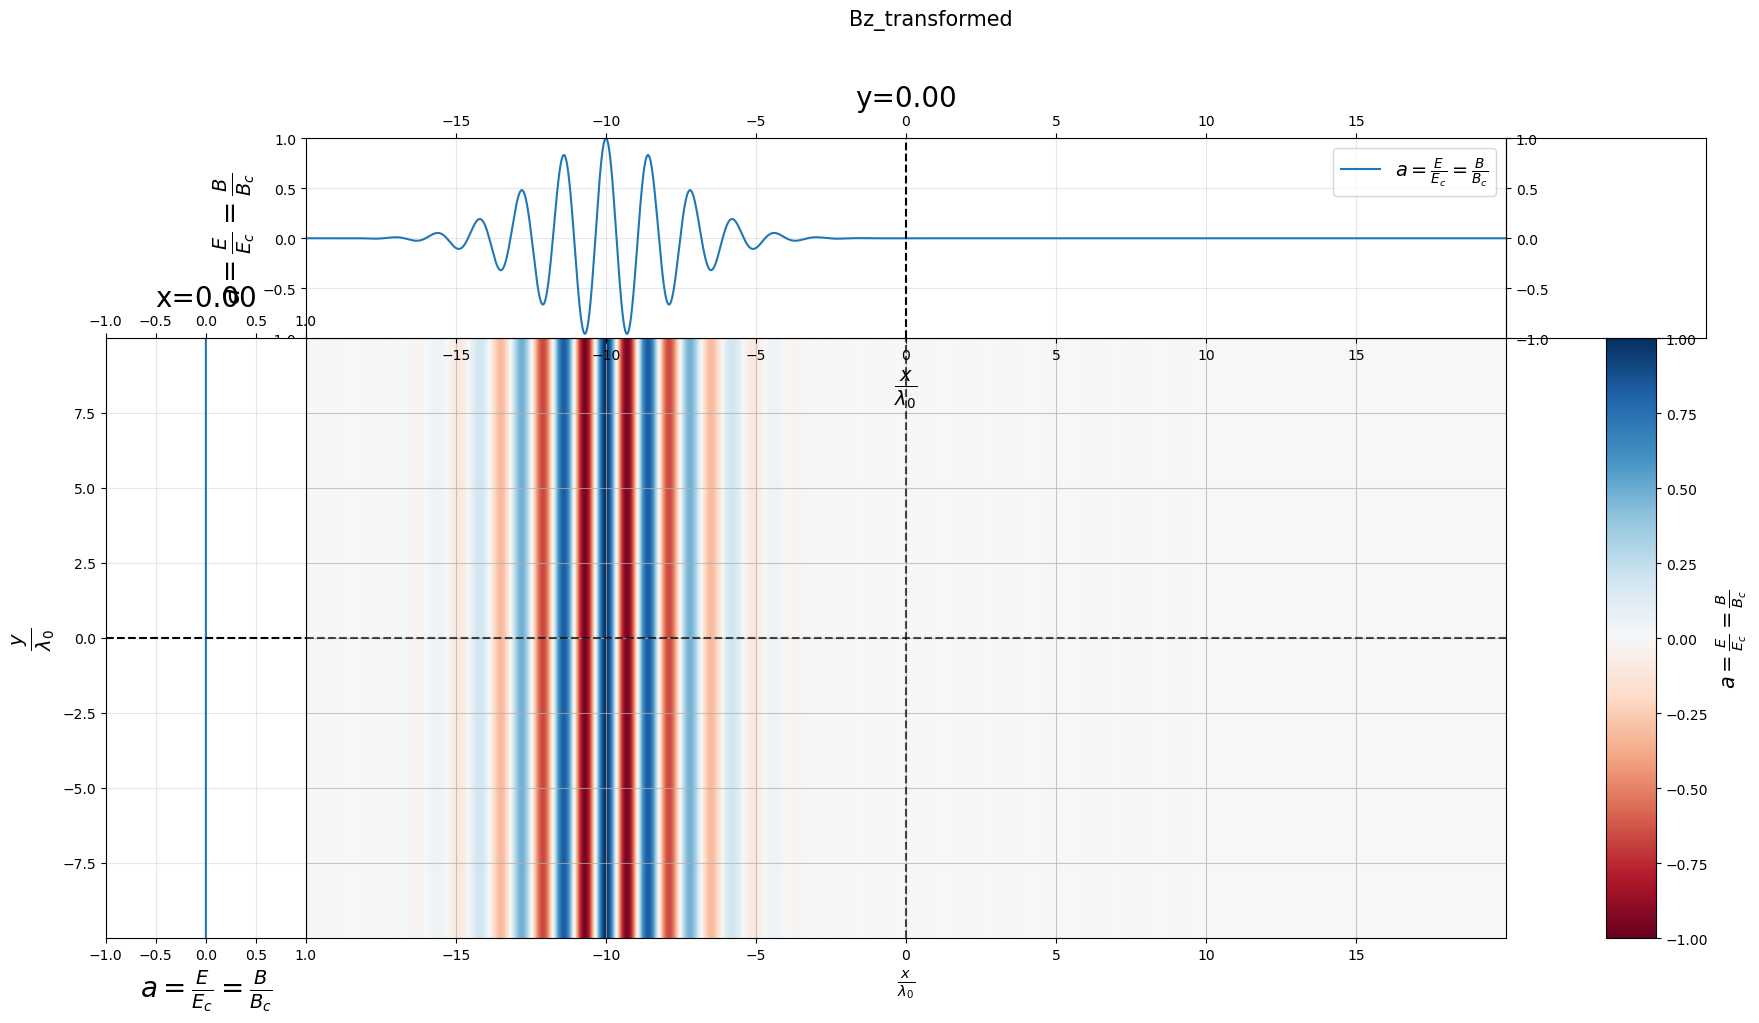

In [12]:
Bz_transformed=B_transformed[2]
plot_2D_field(
    field=Bz_transformed/laser_Bc,
    x_coordinate=x_coordinate[::step]/laser_lambda,
    y_coordinate=x_coordinate[Nx//4:Nx//4+Ny:step]/laser_lambda,
    name='Bz_transformed',
    x_profile_id=round(zoom*Nx//2),y_profile_id=round(zoom*Ny//2),
)

In [12]:
trans=lorentz_transform.transform_field(
    component0=Derived_Number_Density_Electron*(-C.elementary_charge),  # Convert number density to charge density
    component1=Derived_Jx_Electron,
    component2=Derived_Jy_Electron,
    component3=Derived_Jz_Electron,
    four_vector_type='four_current',
    direction='1->0'
)


In [13]:
Ne_L=trans[0]/(-C.elementary_charge)
Jx_L=trans[1]
Jy_L=trans[2]
Jz_L=trans[3]

{'fig': <Figure size 800x600 with 1 Axes>,
 'ax_main': <Axes: xlabel='$\\frac{x}{\\lambda_0}$', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>}

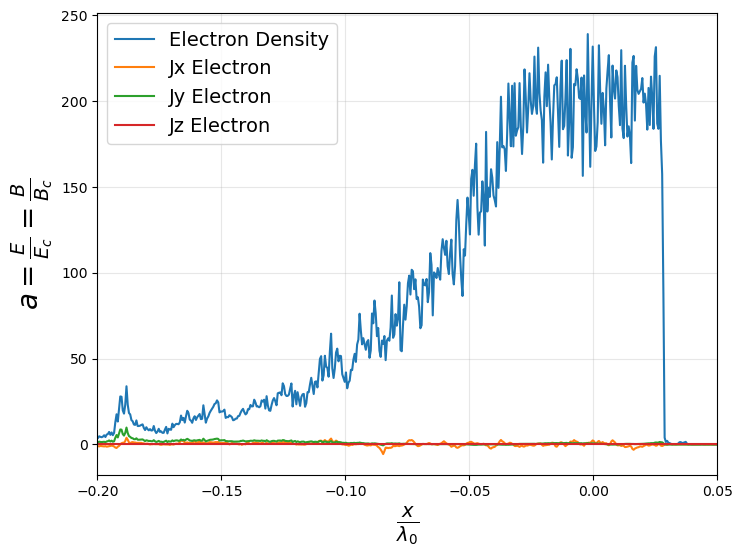

In [14]:
plot_multiple_1D_fields(
    x_coordinate/laser_lambda,
    field_dict_list=[
        {'field': Ne_L/laser_Nc, 'label': 'Electron Density'},
        {'field': Jx_L/(laser_Nc*C.elementary_charge*C.speed_of_light), 'label': 'Jx Electron'},
        {'field': Jy_L/(laser_Nc*C.elementary_charge*C.speed_of_light), 'label': 'Jy Electron'},
        {'field': Jz_L/(laser_Nc*C.elementary_charge*C.speed_of_light), 'label': 'Jz Electron'},
    ],
    xmin=-0.2,xmax=0.05,
)